Install & Import Libraries

In [ ]:
!pip install wordcloud -q

In [ ]:
import re
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [ ]:
class Vocabulary:
    """
    Constructs the model vocabulary from a tokenized corpus.
    """

    def __init__(self, sentences, min_count=2):
        # Count every token across the entire corpus
        raw_counts = Counter(w for sent in sentences for w in sent)

        # Discard rare words below the minimum frequency threshold
        self.word_counts = {w: c for w, c in raw_counts.items() if c >= min_count}

        # Index 0 is reserved for <UNK> and the remaining words are sorted alphabetically
        # for deterministic, reproducible index assignment.
        self.idx2word  = ['<UNK>'] + sorted(self.word_counts.keys())
        self.word2idx  = {w: i for i, w in enumerate(self.idx2word)}
        self.vocab_size = len(self.idx2word)

        # Negative-sampling distribution
        freqs = np.array(
            [self.word_counts.get(w, 0) for w in self.idx2word], dtype=np.float64
        )
        freqs[0] = 0.0           # <UNK> must never be drawn as a negative sample
        freqs    = freqs ** 0.75 # Apply 3/4-power smoothing
        self.neg_probs = freqs / freqs.sum()  # Normalize to a proper distribution

    def __contains__(self, word):
        return word in self.word2idx

    def __len__(self):
        return self.vocab_size

class KeyedVectors:
    """
    Stores word vectors and provides similarity / analogy queries.
    """

    def __init__(self, vocab, W_in):
        self.vocab        = vocab
        self.vectors      = W_in           # shape: (vocab_size, vector_size)
        self.key_to_index = vocab.word2idx

    def __getitem__(self, word):
        """Returns the embedding vector for the word."""
        idx = self.vocab.word2idx.get(word)
        if idx is None:
            raise KeyError(f"'{word}' not in vocabulary")
        return self.vectors[idx].copy()

    def __contains__(self, word):
        return word in self.vocab.word2idx

    def most_similar(self, word=None, positive=None, negative=None, topn=5):
        """
        Finds the top-N words most similar to a query by cosine similarity.

        """
        exclude = set()

        if word is not None:
            # simple nearest-neighbor lookup
            query_vec = self[word].astype(np.float64)
            exclude.add(word)
        else:
            # analogy via vector arithmetic
            # query = sum(positive_vecs) - sum(negative_vecs)
            pos_vecs = [self[w].astype(np.float64) for w in (positive or [])]
            neg_vecs = [self[w].astype(np.float64) for w in (negative or [])]
            query_vec = (
                sum(pos_vecs) if pos_vecs else np.zeros(self.vectors.shape[1])
            ) - (
                sum(neg_vecs) if neg_vecs else np.zeros(self.vectors.shape[1])
            )
            exclude.update(positive or [])
            exclude.update(negative or [])

        # Normalizing the query vector to unit length
        q_norm = np.linalg.norm(query_vec)
        if q_norm < 1e-10:
            return []   # Zero vector — no meaningful similarity can be computed
        query_vec /= q_norm

        # Normalizing all stored embedding vectors row-wise
        vecs  = self.vectors.astype(np.float64)
        norms = np.linalg.norm(vecs, axis=1, keepdims=True)
        norms = np.maximum(norms, 1e-10)  # Guard against zero-norm vectors
        normed = vecs / norms             # shape: (V, D)

        sims = normed @ query_vec          # shape: (V,)

        # Exclude <UNK> and the query words themselves from results
        sims[0] = -np.inf
        for w in exclude:
            idx = self.vocab.word2idx.get(w)
            if idx is not None:
                sims[idx] = -np.inf

        top_idx = np.argsort(sims)[::-1][:topn]
        return [(self.vocab.idx2word[i], float(sims[i])) for i in top_idx]


class Word2Vec:
    """
    Word2Vec trained from scratch using NumPy stochastic gradient descent.

    Supports:
        sg=1  Skip-gram with Negative Sampling
        sg=0  CBOW    with Negative Sampling

    Gradients are derived analytically and applied via SGD.
    Word vectors are taken from W_in after training.
    """

    def __init__(self, sentences, vector_size=100, window=5, min_count=2,
                 sg=1, negative=10, epochs=5, lr=0.025, seed=42):
        np.random.seed(seed)
        random.seed(seed)

        self.vector_size = vector_size
        self.window      = window
        self.negative    = negative
        self.sg          = sg
        self.epochs      = epochs
        self.lr          = lr

        # Building vocabulary from the tokenized corpus
        self.vocab = Vocabulary(sentences, min_count)
        V, D       = self.vocab.vocab_size, vector_size

        # Weight initialization
        self.W_in  = ((np.random.rand(V, D) - 0.5) / D).astype(np.float32)
        self.W_out = np.zeros((V, D), dtype=np.float32)

        # Run the training loop
        self._train(sentences)

        self.wv = KeyedVectors(self.vocab, self.W_in)

    # Sigmoid

    @staticmethod
    def _sigmoid(x):
        """
        Numerically stable sigmoid function: σ(x) = 1 / (1 + e^{-x})

        Naively computing 1/(1+exp(-x)) overflows for very negative x.
        We use the identity exp(x)/(1+exp(x)) for x < 0 to avoid this.
        """
        return np.where(
            x >= 0,
            1.0 / (1.0 + np.exp(-x)),
            np.exp(x) / (1.0 + np.exp(x))
        )


    def _get_neg_samples(self, exclude_set, n):
        """
        Draws n distinct negative-sample word indices from the
        unigram^0.75 distribution, excluding words in exclude_set
        (typically the center word and the positive context word).
        """
        samples = []
        while len(samples) < n:
            # Draw a large batch at once for efficiency
            candidates = np.random.choice(
                self.vocab.vocab_size,
                size=n * 3,
                p=self.vocab.neg_probs
            )
            for idx in candidates:
                if idx not in exclude_set:
                    samples.append(int(idx))
                    if len(samples) == n:
                        break
        return samples


    def _train_skipgram_pair(self, center_idx, context_idx, lr):
        """
        One SGD step for a (center, context) Skip-gram pair.

        """
        neg_indices = self._get_neg_samples({center_idx, context_idx}, self.negative)

        h      = self.W_in[center_idx]                # Hidden vector, shape (D,)
        grad_h = np.zeros(self.vector_size, dtype=np.float32)

        # Positive sample update (label = 1)
        v_pos     = self.W_out[context_idx]
        score_pos = self._sigmoid(float(np.dot(v_pos, h)))
        error_pos = np.float32(score_pos - 1.0)        # σ(s) - 1
        grad_h   += error_pos * v_pos
        self.W_out[context_idx] -= lr * error_pos * h  # Update output embedding

        # Negative sample updates (label = 0)
        for neg_idx in neg_indices:
            v_neg     = self.W_out[neg_idx]
            score_neg = self._sigmoid(float(np.dot(v_neg, h)))
            error_neg = np.float32(score_neg)           # σ(s) - 0
            grad_h   += error_neg * v_neg
            self.W_out[neg_idx] -= lr * error_neg * h

        # Updating center word input embedding
        self.W_in[center_idx] -= lr * grad_h

    # CBOW update

    def _train_cbow_window(self, context_indices, target_idx, lr):
        """
        One SGD step for a CBOW (context_words -> target_word) example.
        """
        if not context_indices:
            return

        neg_indices = self._get_neg_samples(
            {target_idx} | set(context_indices), self.negative
        )

        # Hidden layer = mean of all context word vectors
        h      = self.W_in[context_indices].mean(axis=0)  # shape (D,)
        grad_h = np.zeros(self.vector_size, dtype=np.float32)

        # Positive sample (label = 1)
        v_pos     = self.W_out[target_idx]
        score_pos = self._sigmoid(float(np.dot(v_pos, h)))
        error_pos = np.float32(score_pos - 1.0)
        grad_h   += error_pos * v_pos
        self.W_out[target_idx] -= lr * error_pos * h

        # Negative samples (label = 0)
        for neg_idx in neg_indices:
            v_neg     = self.W_out[neg_idx]
            score_neg = self._sigmoid(float(np.dot(v_neg, h)))
            error_neg = np.float32(score_neg)
            grad_h   += error_neg * v_neg
            self.W_out[neg_idx] -= lr * error_neg * h

        # Distributing gradient equally to all context words
        grad_per_ctx = grad_h / len(context_indices)
        for ctx_idx in context_indices:
            self.W_in[ctx_idx] -= lr * grad_per_ctx


    def _train(self, sentences):
        """
        Full SGD training loop across all epochs.

        Window size: drawn randomly in [1, self.window] per word position,
        as done in the original Word2Vec C implementation. This acts as a
        form of data augmentation and down-weights distant context words.
        """
        word2idx     = self.vocab.word2idx
        total_tokens = sum(len(s) for s in sentences)

        for epoch in range(self.epochs):
            # Linear decay: lr decreases from lr_0 to near-zero over training
            lr = self.lr * (1.0 - epoch / (self.epochs + 1))
            lr = max(lr, self.lr * 1e-4)     # Minimum learning rate floor

            words_seen = 0

            for sent in sentences:
                # Converting words to indices; skip OOV tokens
                indices = [word2idx[w] for w in sent if w in word2idx]
                if len(indices) < 2:
                    continue

                for pos, center_idx in enumerate(indices):
                    # Randomly shrinking the window each step (data augmentation)
                    win = random.randint(1, self.window)

                    lo  = max(0, pos - win)
                    hi  = min(len(indices), pos + win + 1)
                    ctx = [indices[i] for i in range(lo, hi) if i != pos]

                    if not ctx:
                        continue

                    if self.sg == 1:
                        # Skip-gram: train one pair per context word
                        for ctx_idx in ctx:
                            self._train_skipgram_pair(center_idx, ctx_idx, lr)
                    else:
                        # CBOW: train one example for the whole context window
                        self._train_cbow_window(ctx, center_idx, lr)

                    words_seen += 1

            pct = words_seen / max(total_tokens, 1) * 100
            print(f"  Epoch {epoch + 1}/{self.epochs} | lr={lr:.5f} | "
                  f"positions processed: {words_seen:,} ({pct:.0f}% of corpus)")

        print(f"  Training complete. Vocabulary size: {self.vocab.vocab_size}")


    def save(self, path):
        """
        Save W_in, W_out, and vocabulary to a compressed .npz archive.
        """
        np.savez_compressed(
            path,
            W_in      = self.W_in,
            W_out     = self.W_out,
            idx2word  = np.array(self.vocab.idx2word),
            wc_keys   = np.array(list(self.vocab.word_counts.keys())),
            wc_vals   = np.array(list(self.vocab.word_counts.values())),
        )
        print(f"Model saved -> '{path}.npz'")

---
## Task 1: Dataset Preparation


In [ ]:
# File picker

from google.colab import files

print("Please upload your corpus_raw.txt file...")
uploaded = files.upload()

# Verifying the expected file was uploaded
CORPUS_FILENAME = "corpus_raw.txt"
if CORPUS_FILENAME not in uploaded:
    raise FileNotFoundError(
        f"Expected '{CORPUS_FILENAME}' but got: {list(uploaded.keys())}. "
        "Please re-run this cell and upload the correct file."
    )

try:
    raw_text = uploaded[CORPUS_FILENAME].decode("utf-8")
except UnicodeDecodeError:
    raw_text = uploaded[CORPUS_FILENAME].decode("latin-1")

# Wrap in a list so the preprocessing cell below works without any changes
raw_documents = [raw_text]

print(f"\n'corpus_raw.txt' loaded successfully.")
print(f"  Total characters read : {len(raw_text):,}")
print(f"  Preview (first 300 chars):\n")
print(raw_text[:300])

Please upload your corpus_raw.txt file...


Saving corpus_raw.txt to corpus_raw.txt

'corpus_raw.txt' loaded successfully.
  Total characters read : 630,443
  Preview (first 300 chars):

Introduction to IIT Jodhpur 
Indian Institute of Technology Jodhpur was established in 2008 to foster technology education and research in India. The Institute is committed to technological thought and action to benefit the economic development of the country. Scholarship in teaching and learning, 


In [ ]:
def preprocess_text(text):
    """
    Preprocesses raw text into a list of tokenized sentences.
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs (http/https/www)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Step 4: Remove non-ASCII characters (removes Hindi/other language text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Step 5: Split into sentences using common sentence-ending punctuation
    sentences_raw = re.split(r'[.!?;\n]+', text)

    tokenized_sentences = []
    for sent in sentences_raw:
        # Step 6: Remove all punctuation except hyphens in compound words
        sent = re.sub(r'[^a-z0-9\s\-]', ' ', sent)

        # Step 7: Tokenize by whitespace
        tokens = sent.split()

        # Step 8: Remove tokens shorter than 2 characters (noise)
        tokens = [t for t in tokens if len(t) >= 2]

        # Only keep sentences with at least 3 tokens
        if len(tokens) >= 3:
            tokenized_sentences.append(tokens)

    return tokenized_sentences

all_sentences = []
all_tokens_flat = []

for doc in raw_documents:
    sentences = preprocess_text(doc)
    all_sentences.extend(sentences)
    for sent in sentences:
        all_tokens_flat.extend(sent)

# Building Vocabulary
vocab = set(all_tokens_flat)                # Unique word types
word_freq = Counter(all_tokens_flat)        # Word frequency map

print("\n=== DATASET STATISTICS ===")
print(f"  Number of source documents     : {len(raw_documents)}")
print(f"  Total number of sentences      : {len(all_sentences)}")
print(f"  Total number of tokens         : {len(all_tokens_flat)}")
print(f"  Vocabulary size (unique words) : {len(vocab)}")
print(f"  Top 20 most frequent words     :")
for word, count in word_freq.most_common(20):
    print(f"    '{word}': {count}")

Preprocessing corpus...

=== DATASET STATISTICS ===
  Number of source documents     : 1
  Total number of sentences      : 7380
  Total number of tokens         : 82117
  Vocabulary size (unique words) : 7851
  Top 20 most frequent words     :
    'the': 4915
    'of': 3976
    'and': 2950
    'in': 2022
    'to': 1888
    'for': 1515
    'be': 833
    'is': 669
    'with': 652
    'as': 634
    'student': 588
    'research': 571
    'by': 559
    'at': 541
    'on': 526
    'engineering': 525
    'will': 500
    'or': 491
    'department': 431
    'from': 415


In [ ]:
# Saving cleaned corpus to file

CORPUS_FILE = "iitj_clean_corpus.txt"

with open(CORPUS_FILE, "w", encoding="utf-8") as f:
    for sent in all_sentences:
        f.write(" ".join(sent) + "\n")

print(f"Clean corpus saved to '{CORPUS_FILE}'")
print(f"File size: {os.path.getsize(CORPUS_FILE)} bytes")

Clean corpus saved to 'iitj_clean_corpus.txt'
File size: 558084 bytes


Top-10 words (excluding stopwords) for word cloud:
   1. student              588
   2. research             571
   3. engineering          525
   4. department           431
   5. institute            411
   6. students             391
   7. program              388
   8. jodhpur              366
   9. semester             314
  10. course               309


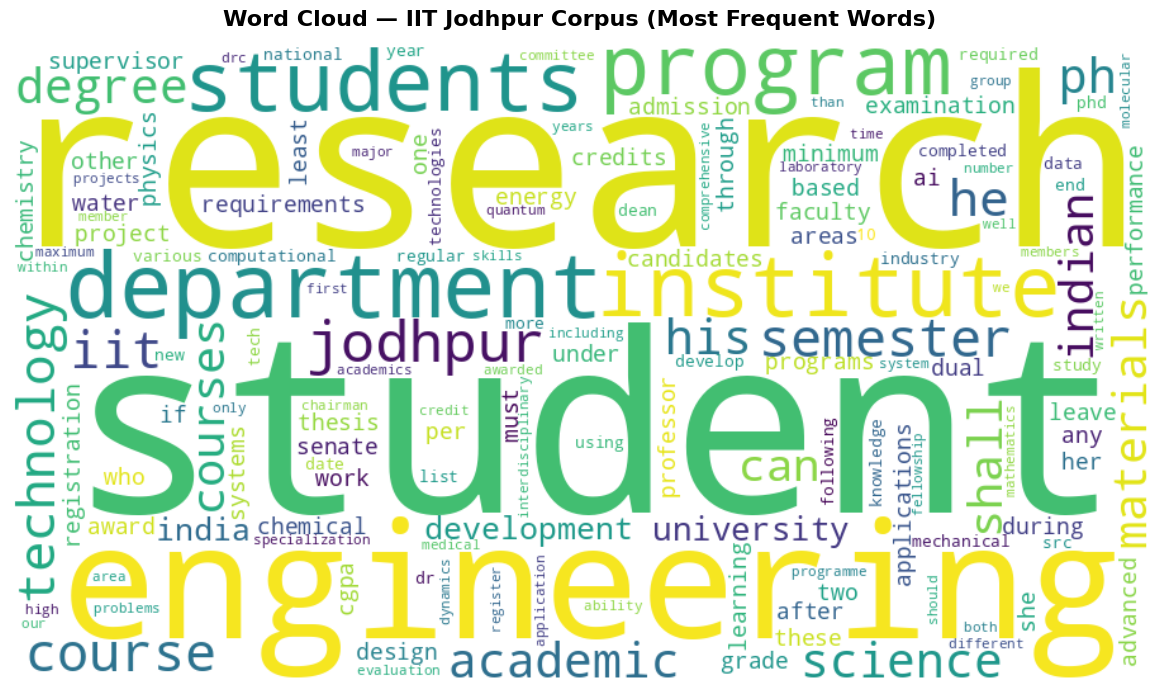

Word cloud saved as 'wordcloud_iitj.png'


In [ ]:
# Word Cloud Visualization
STOPWORDS_WC = {
    'the', 'and', 'of', 'in', 'to', 'is', 'are', 'for', 'with',
    'on', 'at', 'by', 'an', 'as', 'be', 'it', 'or', 'from', 'this',
    'that', 'all', 'its', 'has', 'have', 'will', 'been', 'their',
    'not', 'was', 'also', 'which', 'may', 'they', 'such', 'each'
}

# Build frequency dict excluding stopwords for word cloud
wc_freq = {w: c for w, c in word_freq.items() if w not in STOPWORDS_WC}

# Report top-10 words by frequency (excluding stopwords)
print("Top-10 words (excluding stopwords) for word cloud:")
top10_wc = sorted(wc_freq.items(), key=lambda x: x[1], reverse=True)[:10]
for rank, (word, freq) in enumerate(top10_wc, 1):
    print(f"  {rank:>2}. {word:<20} {freq}")

wc = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=150,
    prefer_horizontal=0.85,
)
wc.generate_from_frequencies(wc_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — IIT Jodhpur Corpus (Most Frequent Words)",
          fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Task 2: Model Training


In [ ]:
import time

HYPERPARAMS = [
    # (embedding_dim, window_size, negative_samples)
    (50,  3,  5),    # Config A: small embedding, small window
    (100, 5,  10),   # Config B: medium embedding — best overall balance
    (300, 9,  20),   # Config C: large embedding, large window
]

EPOCHS    = 30    # Epochs per model
MIN_COUNT = 2     # Ignore words with frequency < MIN_COUNT

cbow_models     = {}  # (dim, win, neg) -> trained CBOW model
skipgram_models = {}  # (dim, win, neg) -> trained Skip-gram model

print("Training Word2Vec models...")
print(f"{'Model':<12} {'Dim':>5} {'Win':>5} {'Neg':>5} | {'Vocab':>8} {'Time(s)':>9}")
print("-" * 55)

for dim, win, neg in HYPERPARAMS:
    key = (dim, win, neg)

    for model_type, sg_flag in [("CBOW", 0), ("Skip-gram", 1)]:
        print(f"\n[ {model_type} | dim={dim}, win={win}, neg={neg} ]")
        t_start = time.time()

        # Instantiate and train the from-scratch Word2Vec model.
        # sg=0 -> CBOW   (predicts center word from context mean)
        # sg=1 -> Skip-gram  (predicts each context word from center)
        # Both use Negative Sampling as the training objective.
        model = Word2Vec(
            sentences=all_sentences,
            vector_size=dim,
            window=win,
            min_count=MIN_COUNT,
            sg=sg_flag,                # 0=CBOW, 1=Skip-gram
            negative=neg,
            epochs=EPOCHS,
            seed=42,
        )

        elapsed    = time.time() - t_start
        vocab_size = len(model.wv.key_to_index)

        print(f"{model_type:<12} {dim:>5} {win:>5} {neg:>5} | {vocab_size:>8} {elapsed:>9.2f}")

        if sg_flag == 0:
            cbow_models[key] = model
        else:
            skipgram_models[key] = model

print("\nAll models trained.")

Training Word2Vec models (from scratch — NumPy SGD)...
Model          Dim   Win   Neg |    Vocab   Time(s)
-------------------------------------------------------

[ CBOW | dim=50, win=3, neg=5 ]
  Epoch 1/30 | lr=0.02500 | positions processed: 78,614 (96% of corpus)
  Epoch 2/30 | lr=0.02419 | positions processed: 78,614 (96% of corpus)
  Epoch 3/30 | lr=0.02339 | positions processed: 78,614 (96% of corpus)
  Epoch 4/30 | lr=0.02258 | positions processed: 78,614 (96% of corpus)
  Epoch 5/30 | lr=0.02177 | positions processed: 78,614 (96% of corpus)
  Epoch 6/30 | lr=0.02097 | positions processed: 78,614 (96% of corpus)
  Epoch 7/30 | lr=0.02016 | positions processed: 78,614 (96% of corpus)
  Epoch 8/30 | lr=0.01935 | positions processed: 78,614 (96% of corpus)
  Epoch 9/30 | lr=0.01855 | positions processed: 78,614 (96% of corpus)
  Epoch 10/30 | lr=0.01774 | positions processed: 78,614 (96% of corpus)
  Epoch 11/30 | lr=0.01694 | positions processed: 78,614 (96% of corpus)
  Epoch 12

In [ ]:
# Printing 300-dim embedding for "research" from Config C Skip-gram
CONFIG_C_KEY = (300, 9, 20)
if CONFIG_C_KEY in skipgram_models:
    model_c = skipgram_models[CONFIG_C_KEY]
    if "research" in model_c.wv.key_to_index:
        vec = model_c.wv["research"]
        vec_str = ", ".join(f"{v:.4f}" for v in vec)
        print(f"\nresearch - {vec_str}")
    else:
        print("\n'research' not found in Config C Skip-gram vocabulary.")
else:
    print("\nConfig C (300, 9, 20) model not found.")


research - 0.0079, -0.4129, 0.4473, 0.3287, -0.3556, 0.4193, 0.2590, -0.0328, -0.0760, 0.2865, -0.1173, -0.2209, -0.0268, -0.0908, 0.2278, -0.4300, -0.1627, 0.0765, 0.1143, -0.2570, 0.0708, -0.2298, -0.1489, -0.0415, 0.3053, 0.6558, 0.1152, -0.2490, -0.0799, 0.3851, 0.0237, 0.0128, 0.0924, 0.1182, -0.0642, 0.2642, -0.0206, -0.2553, -0.2445, -0.0497, -0.3078, 0.1947, -0.1708, 0.0500, 0.1537, 0.5479, -0.2446, -0.0549, 0.0757, 0.0922, -0.1538, -0.3104, 0.2057, 0.2273, 0.3199, 0.1737, -0.0767, -0.2093, 0.2251, 0.1760, 0.0203, 0.2523, 0.1257, -0.3128, 0.1185, 0.0528, -0.1174, 0.2080, 0.0787, -0.0121, -0.3580, -0.3471, 0.0268, 0.4656, 0.1273, 0.5253, 0.1309, 0.0407, -0.2835, 0.2842, -0.1037, 0.3654, -0.1898, -0.0275, 0.1656, 0.0932, -0.3181, -0.0967, 0.1976, 0.0804, 0.4069, 0.4899, -0.1960, 0.5188, -0.2299, -0.5728, -0.1807, 0.0881, 0.1472, 0.2167, 0.4716, -0.0804, -0.1848, 0.0370, -0.1376, -0.0766, 0.3329, 0.0447, 0.1949, -0.2811, 0.3491, 0.0002, 0.0875, -0.4433, -0.6382, 0.1408, -0.4462, 

In [ ]:
# Config B (dim=100, window=5, neg=10) is selected as the best model.
# It offers a good balance between embedding quality and training time.

BEST_KEY = (100, 5, 10)

best_cbow     = cbow_models[BEST_KEY]
best_skipgram = skipgram_models[BEST_KEY]

print(f"Best CBOW model     : dim={BEST_KEY[0]}, window={BEST_KEY[1]}, neg={BEST_KEY[2]}")
print(f"  Vocabulary size   : {len(best_cbow.wv.key_to_index)}")
print(f"Best Skip-gram model: dim={BEST_KEY[0]}, window={BEST_KEY[1]}, neg={BEST_KEY[2]}")
print(f"  Vocabulary size   : {len(best_skipgram.wv.key_to_index)}")

# Save model weights to compressed NumPy archives (.npz)
best_cbow.save("w2v_cbow_best")
best_skipgram.save("w2v_skipgram_best")
print("\nBest models saved to disk as .npz archives.")

Best CBOW model     : dim=100, window=5, neg=10
  Vocabulary size   : 4372
Best Skip-gram model: dim=100, window=5, neg=10
  Vocabulary size   : 4372
Model saved -> 'w2v_cbow_best.npz'
Model saved -> 'w2v_skipgram_best.npz'

Best models saved to disk as .npz archives.


In [ ]:
# Summary Table of All Experiments
import pandas as pd

rows = []
for (dim, win, neg), m in cbow_models.items():
    rows.append({"Model": "CBOW", "Dim": dim, "Window": win,
                 "NegSamples": neg, "VocabSize": len(m.wv.key_to_index)})
for (dim, win, neg), m in skipgram_models.items():
    rows.append({"Model": "Skip-gram", "Dim": dim, "Window": win,
                 "NegSamples": neg, "VocabSize": len(m.wv.key_to_index)})

df_results = pd.DataFrame(rows).sort_values(["Model", "Dim"]).reset_index(drop=True)
print("\n=== Hyperparameter Experiment Summary ===")
print(df_results.to_string(index=False))


=== Hyperparameter Experiment Summary ===
    Model  Dim  Window  NegSamples  VocabSize
     CBOW   50       3           5       4372
     CBOW  100       5          10       4372
     CBOW  300       9          20       4372
Skip-gram   50       3           5       4372
Skip-gram  100       5          10       4372
Skip-gram  300       9          20       4372


---
## Task 3: Semantic Analysis

### 3.1 — Top-5 Nearest Neighbors (Cosine Similarity)

In [ ]:
def nearest_neighbors(model, word, topn=5):
    """
    Retrieves the top-N most similar words to the given word
    using cosine similarity on the embedding vectors.
    """
    if word not in model.wv.key_to_index:
        return [(f"'{word}' NOT IN VOCABULARY", 0.0)]
    return model.wv.most_similar(word, topn=topn)


# Words to analyze as specified in the assignment
QUERY_WORDS = ["research", "student", "phd", "exam", "professor"]

print("=" * 65)
print("TOP-5 NEAREST NEIGHBORS (Cosine Similarity)")
print("=" * 65)

for word in QUERY_WORDS:
    print(f"\nQuery word: '{word}'")
    print(f"  {'Rank':<6} {'CBOW Neighbor':<25} {'Sim':>6}  "
          f"{'Skip-gram Neighbor':<25} {'Sim':>6}")
    print(f"  {'-'*4:<6} {'-'*23:<25} {'-'*6}  {'-'*23:<25} {'-'*6}")

    cbow_nn = nearest_neighbors(best_cbow, word)
    sg_nn   = nearest_neighbors(best_skipgram, word)

    for rank, (c_pair, s_pair) in enumerate(zip(cbow_nn, sg_nn), 1):
        c_word, c_sim = c_pair
        s_word, s_sim = s_pair
        print(f"  {rank:<6} {c_word:<25} {c_sim:>6.4f}  {s_word:<25} {s_sim:>6.4f}")

TOP-5 NEAREST NEIGHBORS (Cosine Similarity)

Query word: 'research'
  Rank   CBOW Neighbor                Sim  Skip-gram Neighbor           Sim
  ----   -----------------------   ------  -----------------------   ------
  1      collaborative             0.7285  educational               0.5297
  2      projects                  0.7243  kalpakkam                 0.5250
  3      interests                 0.7112  projects                  0.5208
  4      group                     0.7100  lie                       0.5193
  5      current                   0.6966  deep-tech                 0.5132

Query word: 'student'
  Rank   CBOW Neighbor                Sim  Skip-gram Neighbor           Sim
  ----   -----------------------   ------  -----------------------   ------
  1      not                       0.8109  cannot                    0.6248
  2      candidate                 0.8024  unable                    0.5983
  3      register                  0.7715  maintain                  0.59

### 3.2 — Analogy Experiments

In [ ]:
def word_analogy(model, word_a, word_b, word_c, topn=3):
    """
    Solves word analogies of the form: A:B :: C : ?

    Uses the classic vector arithmetic approach:
        result_vector = vec(B) - vec(A) + vec(C)
    """
    # Check all words are in vocabulary before attempting
    missing = [w for w in [word_a, word_b, word_c]
               if w not in model.wv.key_to_index]
    if missing:
        return [(f"Missing vocab: {missing}", 0.0)]

    results = model.wv.most_similar(
        positive=[word_b, word_c],  # B + C
        negative=[word_a],          # - A
        topn=topn
    )
    return results


# Defining analogy experiments
ANALOGIES = [
    # (A, B, C, description)
    ("ug",       "btech",    "pg",       "UG:BTech :: PG:?"),
    ("student",  "exam",     "faculty",  "student:exam :: faculty:?"),
    ("research", "phd",      "teaching", "research:phd :: teaching:?"),
    ("jodhpur",  "iit",      "bombay",   "jodhpur:iit :: bombay:?"),
]

print("=" * 70)
print("ANALOGY EXPERIMENTS")
print("=" * 70)

for a, b, c, desc in ANALOGIES:
    print(f"\nAnalogy: {desc}  (i.e., vec({b}) - vec({a}) + vec({c}))")
    print(f"  {'CBOW Results':<35}  {'Skip-gram Results':<35}")
    print(f"  {'-'*33}  {'-'*33}")

    cbow_results = word_analogy(best_cbow,     a, b, c)
    sg_results   = word_analogy(best_skipgram, a, b, c)

    for cr, sr in zip(cbow_results, sg_results):
        cw, cs = cr
        sw, ss = sr
        print(f"  {cw:<28} ({cs:.4f})    {sw:<28} ({ss:.4f})")

ANALOGY EXPERIMENTS

Analogy: UG:BTech :: PG:?  (i.e., vec(btech) - vec(ug) + vec(pg))
  CBOW Results                         Skip-gram Results                  
  ---------------------------------  ---------------------------------
  pandey                       (0.8560)    mba                          (0.6737)
  stringent                    (0.8529)    dgpa                         (0.6005)
  chandan                      (0.8518)    nit                          (0.5952)

Analogy: student:exam :: faculty:?  (i.e., vec(exam) - vec(student) + vec(faculty))
  CBOW Results                         Skip-gram Results                  
  ---------------------------------  ---------------------------------
  industry                     (0.3973)    members                      (0.5626)
  dst                          (0.3711)    advisor                      (0.4706)
  members                      (0.3637)    imsc                         (0.4426)

Analogy: research:phd :: teaching:?  (i.e., vec(p

---
## Task 4: Visualization with PCA and t-SNE

In [ ]:
# Defining semantic word groups to visualize
# Words are grouped by semantic category to see if the model
# correctly clusters related concepts together.

WORD_GROUPS = {
    "Academic Programs" : ["btech", "mtech", "phd", "msc", "ug", "pg"],
    "Research"          : ["research", "publication", "thesis", "project", "lab"],
    "People"            : ["student", "faculty", "professor", "scholar", "instructor"],
    "Evaluation"        : ["exam", "grade", "cgpa", "marks", "semester"],
    "Departments"       : ["computer", "electrical", "mechanical", "chemistry", "physics"],
}

def filter_vocab(model, word_groups):
    """
    Filters word groups to only include words present in model vocabulary.
    """
    words, labels = [], []
    for group_name, group_words in word_groups.items():
        for w in group_words:
            if w in model.wv.key_to_index:
                words.append(w)
                labels.append(group_name)
    vectors = np.array([model.wv[w] for w in words])
    return words, labels, vectors


def plot_embeddings(ax, coords, words, labels, title, group_names, colors):
    """
    Plots 2D word embeddings with color-coded semantic groups.
    """
    color_map = dict(zip(group_names, colors))
    plotted_groups = set()

    for i, (word, label) in enumerate(zip(words, labels)):
        c = color_map[label]
        # Add legend entry only for first occurrence of each group
        legend_label = label if label not in plotted_groups else None
        ax.scatter(coords[i, 0], coords[i, 1], c=[c], s=80,
                   label=legend_label, zorder=3)
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=8.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')
        plotted_groups.add(label)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='best', framealpha=0.7)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")


# Shared color palette for word groups
GROUP_NAMES = list(WORD_GROUPS.keys())
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

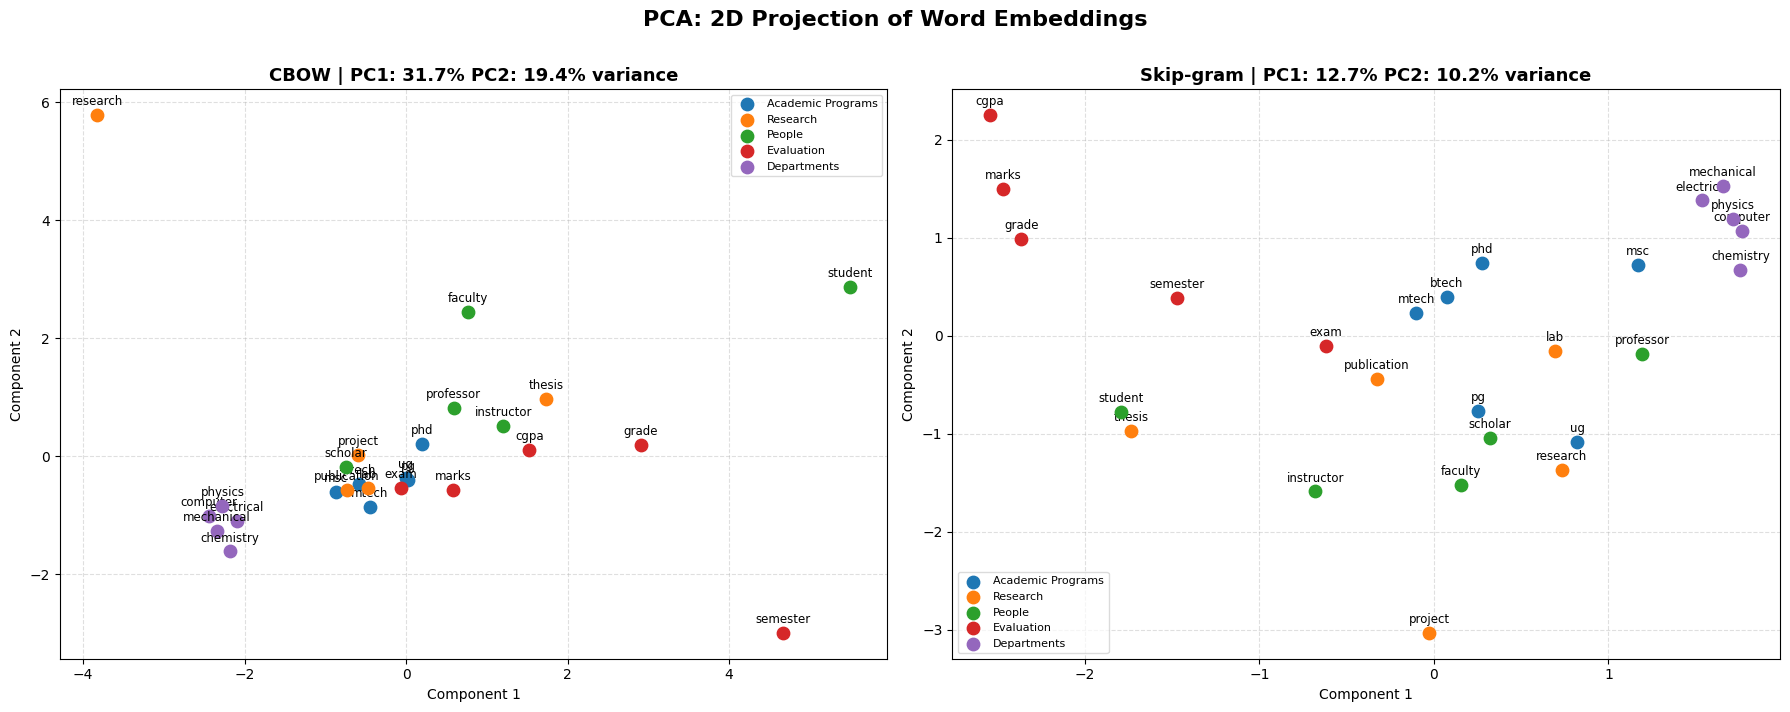

In [ ]:
# PCA Visualization
# Words with similar contexts should cluster together.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("PCA: 2D Projection of Word Embeddings",
             fontsize=16, fontweight='bold', y=1.01)

for ax, (model_name, model) in zip(
        axes, [("CBOW", best_cbow), ("Skip-gram", best_skipgram)]):

    words, labels, vectors = filter_vocab(model, WORD_GROUPS)

    if len(words) < 2:
        ax.text(0.5, 0.5, "Not enough vocabulary for visualization",
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(vectors)   # Shape: (N, 2)

    variance_explained = pca.explained_variance_ratio_ * 100
    subtitle = (f"{model_name} | PC1: {variance_explained[0]:.1f}% "
                f"PC2: {variance_explained[1]:.1f}% variance")

    plot_embeddings(ax, coords_2d, words, labels, subtitle, GROUP_NAMES, COLORS)

plt.tight_layout()
plt.show()

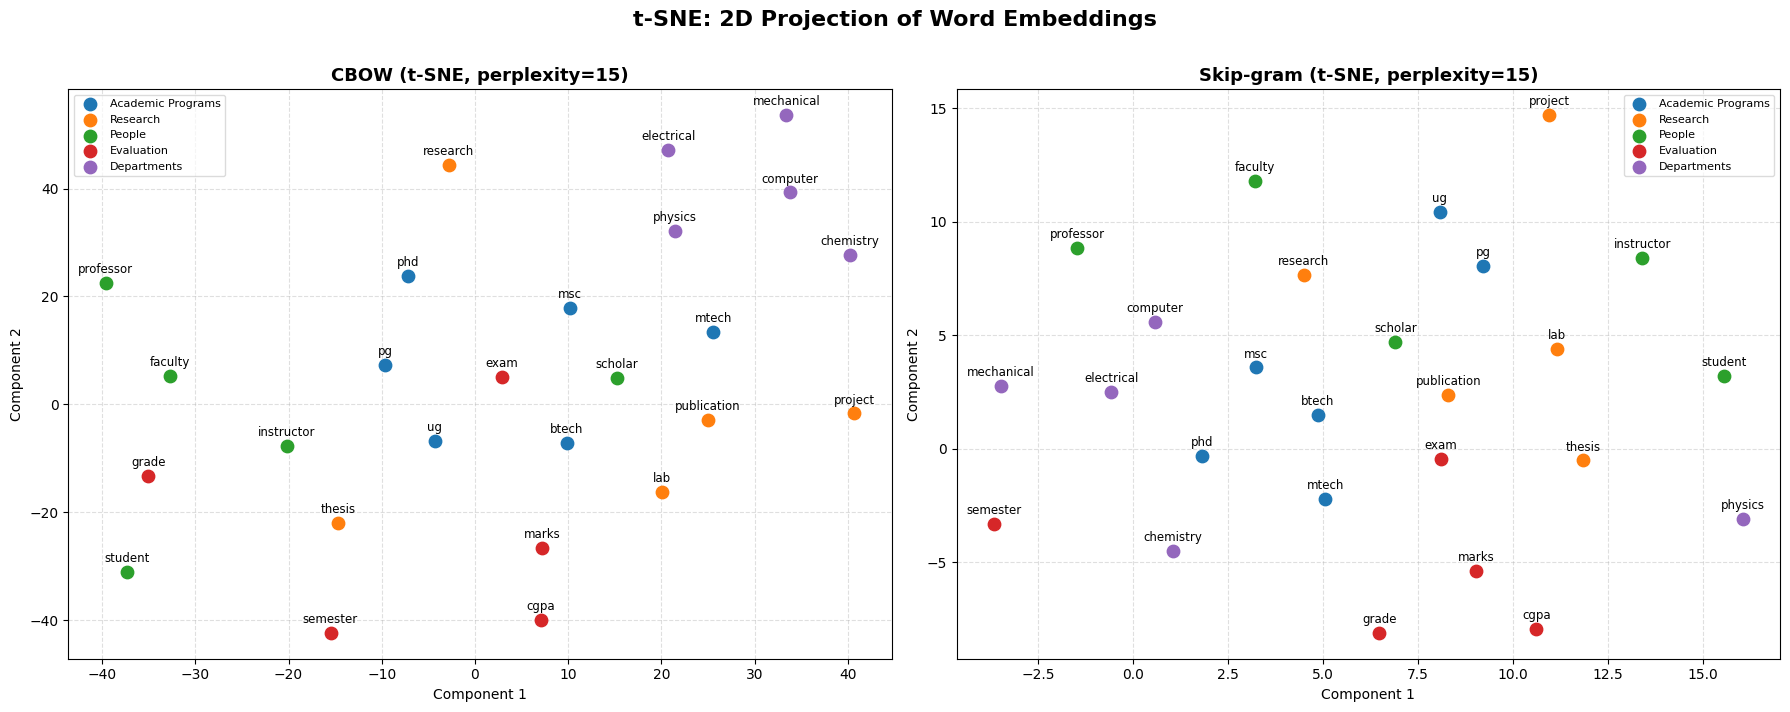

In [ ]:
# t-SNE Visualization

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("t-SNE: 2D Projection of Word Embeddings",
             fontsize=16, fontweight='bold', y=1.01)

for ax, (model_name, model) in zip(
        axes, [("CBOW", best_cbow), ("Skip-gram", best_skipgram)]):

    words, labels, vectors = filter_vocab(model, WORD_GROUPS)

    if len(words) < 5:
        ax.text(0.5, 0.5, "Not enough vocabulary for t-SNE",
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Perplexity must be < number of samples; typically 5-50
    perplexity = min(15, len(words) - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=1000,          # Number of gradient descent iterations
        random_state=42,
        learning_rate='auto',
        init='pca',           # PCA initialization is more stable
    )
    coords_2d = tsne.fit_transform(vectors)

    plot_embeddings(ax, coords_2d, words, labels,
                   f"{model_name} (t-SNE, perplexity={perplexity})",
                   GROUP_NAMES, COLORS)

plt.tight_layout()
plt.show()